<a href="https://colab.research.google.com/github/arunimamuralitharan/wav2lip_demo_ttsvideo/blob/main/wav2lip_llmenhanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1)} GB')
else:
    print('No GPU detected')

GPU: Tesla T4
VRAM: 15.6 GB


In [2]:
print('Installing Wav2Lip...')
!git clone https://github.com/Rudrabha/Wav2Lip /content/Wav2Lip -q
!pip install -r /content/Wav2Lip/requirements.txt -q
!pip install librosa==0.9.2 -q

print('Installing Gemini SDK...')
!pip install google-generativeai -q

print('Installing Coqui TTS (free neural TTS)...')
!pip install TTS -q

print('\nAll dependencies installed')

Installing Wav2Lip...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 126.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: Ignored the following yanked versions: 3.4.11.39, 3.4.17.61, 4.4.0.42, 4.4.0.44, 4.5.4.58, 4.5.5.62, 4.7.0.68
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement opencv-python==4.1.0.25 (from versions: 3.4.0.14, 3.4.10.37, 3.4.11.41, 3.4.11.43, 3.4.11.45, 3.4.13.47, 3.4.15.55, 3.4.16.57, 3.4.16.59, 3.4.17.63, 3.4.18.65, 4.3.0.38, 4.4.0.40, 4.4.0.46, 4.5.1.48, 4.5.3.56, 4.5.4.60, 4.5.5.64, 4.6.0.66, 4.7.0.72, 4.8.0.74, 4.8.0.76, 4.8.1.78, 4.9.0.80, 4.10.0.82

In [10]:
print('Installing Kokoro TTS')
!pip install kokoro>=0.9.4 soundfile -q
!apt-get -qq -y install espeak-ng > /dev/null 2>&1

Installing Kokoro TTS


In [3]:
import os

os.makedirs('/content/Wav2Lip/checkpoints', exist_ok=True)

!wget -q --show-progress \
  'https://huggingface.co/numz/wav2lip_studio/resolve/main/Wav2lip/wav2lip_gan.pth' \
  -O /content/Wav2Lip/checkpoints/wav2lip_gan.pth

size = os.path.getsize('/content/Wav2Lip/checkpoints/wav2lip_gan.pth') / 1e6
print(f'Checkpoint downloaded: {size:.1f} MB')

/content/Wav2Lip/ch 100%[===================>] 415.61M   351MB/s    in 1.2s    
Checkpoint downloaded: 435.8 MB


In [6]:
from google.colab import userdata
import google.generativeai as genai

GEMINI_KEY = userdata.get('scriptgem')

if GEMINI_KEY:
    genai.configure(api_key=GEMINI_KEY)
    model_gemini = genai.GenerativeModel('gemini-2.5-flash-lite')
    print('Gemini 2.5 Flash Lite API ready')
else:
    print('GEMINI_API_KEY not found in Secrets')

Gemini 2.5 Flash Lite API ready


In [7]:
def generate_script(topic, tone='friendly and conversational', duration_seconds=20):
    """
    Generate a natural spoken script using Gemini 1.5 Flash (free).

    Args:
        topic           : What the video should be about
        tone            : e.g. 'professional', 'excited', 'calm and warm'
        duration_seconds: Target speech length
    """
    approx_words = int(duration_seconds * 2.5)  # ~150 wpm

    prompt = f"""Write a {tone} spoken script about: {topic}

Rules:
- Target approximately {approx_words} words (for ~{duration_seconds} seconds of speech)
- Write exactly how people speak, not how they write
- Use short sentences and natural pauses with commas and ellipses
- Avoid formal language, bullet points, or markdown
- Start immediately with no title or preamble
- Output ONLY the script text, nothing else"""

    response = model_gemini.generate_content(prompt)
    return response.text.strip()

TOPIC    = 'why getting enough sleep makes you smarter and more creative'
TONE     = 'warm, friendly, and slightly enthusiastic'
DURATION = 25  # seconds

script = generate_script(TOPIC, TONE, DURATION)

print('Generated Script:')
print('─' * 50)
print(script)
print('─' * 50)
print(f'Word count: {len(script.split())}')

Generated Script:
──────────────────────────────────────────────────
You know... getting enough sleep, it's like… a superpower! Seriously.  When you're well-rested, your brain… it just works better.  You can focus more, remember stuff easier.  And creativity? Oh yeah!  A good night's sleep… it sparks those awesome ideas, makes you think outside the box.  So yeah, sleep smart, sleep creative!
──────────────────────────────────────────────────
Word count: 51


In [11]:
from kokoro import KPipeline
from IPython.display import Audio, display
import soundfile as sf
import numpy as np
import torch

VOICE = 'af_heart'

print(f'Loading Kokoro TTS (voice: {VOICE})...')
print('First run downloads ~350MB model weights.')

pipeline = KPipeline(lang_code='a')  # 'a' = American English

# Generate audio — Kokoro returns audio chunks
audio_chunks = []
for _, _, audio in pipeline(script, voice=VOICE, speed=0.95):
    audio_chunks.append(audio)

audio_out = np.concatenate(audio_chunks)

# Save at Kokoro's native 24kHz, then resample to 16kHz for Wav2Lip
sf.write('/content/speech_raw.wav', audio_out, 24000)
!ffmpeg -y -i /content/speech_raw.wav -ar 16000 -ac 1 /content/speech.wav -loglevel quiet

print('\nAudio generated')
print('Preview:')
display(Audio('/content/speech.wav'))

Loading Kokoro TTS (voice: af_heart)...
First run downloads ~350MB model weights.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


kokoro-v1_0.pth:   0%|          | 0.00/327M [00:00<?, ?B/s]

voices/af_heart.pt:   0%|          | 0.00/523k [00:00<?, ?B/s]


Audio generated
Preview:


Face downloaded: /content/face.jpg


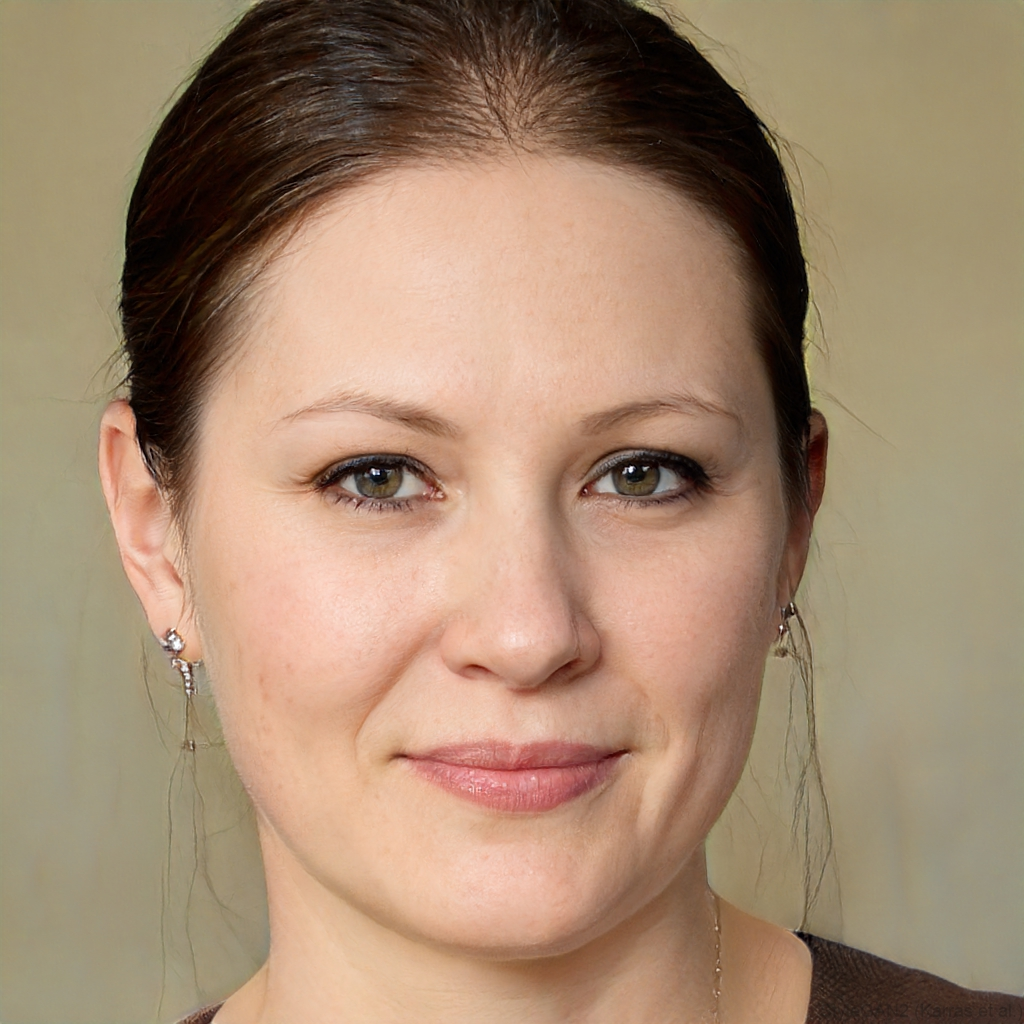

In [12]:
import requests
from IPython.display import Image, display
import os
USE_OWN_FILE = False

if not USE_OWN_FILE:
    response = requests.get(
        'https://thispersondoesnotexist.com',
        headers={'User-Agent': 'Mozilla/5.0'}
    )
    with open('/content/face.jpg', 'wb') as f:
        f.write(response.content)
    face_path = '/content/face.jpg'
    print(f'Face downloaded: {face_path}')
    display(Image(face_path, width=256))
else:
    face_path = '/content/your_face.mp4'
    assert os.path.exists(face_path), f'File not found: {face_path}'
    print(f'Using your file: {face_path}')

In [13]:
import os

os.makedirs('/content/Wav2Lip/temp', exist_ok=True)

assert os.path.exists(face_path),             f'Face not found: {face_path}'
assert os.path.exists('/content/speech.wav'), 'Audio not found — re-run Cell 6'
assert os.path.exists('/content/Wav2Lip/checkpoints/wav2lip_gan.pth'), 'Checkpoint missing — re-run Cell 3'

print('Running Wav2Lip...')

!cd /content/Wav2Lip && python inference.py \
  --checkpoint_path checkpoints/wav2lip_gan.pth \
  --face {face_path} \
  --audio /content/speech.wav \
  --outfile /content/output_raw.mp4 \
  --resize_factor 1

if os.path.exists('/content/output_raw.mp4'):
    size = os.path.getsize('/content/output_raw.mp4') / 1e6
    print(f'\nDone. Raw output: /content/output_raw.mp4 ({size:.1f} MB)')
    FINAL_VIDEO = '/content/output_raw.mp4'
else:
    print('Output not found — check errors above')

Running Wav2Lip...
Using cuda for inference.
Number of frames available for inference: 1
/content/Wav2Lip/audio.py:100: FutureWarning: Pass sr=16000, n_fft=800 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  return librosa.filters.mel(hp.sample_rate, hp.n_fft, n_mels=hp.num_mels,
(80, 1575)
Length of mel chunks: 489
  0% 0/4 [00:00<?, ?it/s]Downloading: "https://www.adrianbulat.com/downloads/python-fan/s3fd-619a316812.pth" to /root/.cache/torch/hub/checkpoints/s3fd-619a316812.pth

  0% 0.00/85.7M [00:00<?, ?B/s]
  0% 128k/85.7M [00:00<03:38, 410kB/s]
  0% 256k/85.7M [00:00<02:34, 582kB/s]
  1% 512k/85.7M [00:00<01:31, 976kB/s]
  1% 896k/85.7M [00:00<00:59, 1.49MB/s]
  2% 1.75M/85.7M [00:00<00:30, 2.89MB/s]
  4% 3.38M/85.7M [00:01<00:15, 5.41MB/s]
  7% 5.88M/85.7M [00:01<00:09, 8.79MB/s]
 11% 9.00M/85.7M [00:01<00:06, 12.5MB/s]
 14% 12.4M/85.7M [00:01<00:04, 15.5MB/s]
 19% 16.1M/85.7M [00:01<00:04, 17.9MB/s]
 23% 19.9M/85.7M [00:01<00:0

In [14]:
import os

if not os.path.exists('/content/GFPGAN'):
    print('Cloning GFPGAN...')
    !git clone https://github.com/TencentARC/GFPGAN /content/GFPGAN -q
    %cd /content/GFPGAN
    !pip install basicsr facexlib -q
    !pip install -r requirements.txt -q
    os.makedirs('experiments/pretrained_models', exist_ok=True)
    !wget -q --show-progress \
      https://github.com/TencentARC/GFPGAN/releases/download/v1.3.0/GFPGANv1.3.pth \
      -P experiments/pretrained_models
    print('GFPGAN ready')

%cd /content/GFPGAN
os.makedirs('/content/enhanced', exist_ok=True)

print('Running face enhancement...')
!python inference_gfpgan.py \
  -i /content/output_raw.mp4 \
  -o /content/enhanced \
  -v 1.3 -s 1 \
  --bg_upsampler none \
  --only_center_face

enhanced_path = '/content/enhanced/restored_imgs/output_raw.mp4'
if os.path.exists(enhanced_path):
    !cp {enhanced_path} /content/output_enhanced.mp4
    size = os.path.getsize('/content/output_enhanced.mp4') / 1e6
    print(f'\nEnhanced: /content/output_enhanced.mp4 ({size:.1f} MB)')
    FINAL_VIDEO = '/content/output_enhanced.mp4'
else:
    print('Enhancement output not found — using raw video')
    FINAL_VIDEO = '/content/output_raw.mp4'

Cloning GFPGAN...
/content/GFPGAN
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 14.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 103.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 26.5 MB/s eta 0:00:00
GFPGANv1.3.pth      100%[===================>] 332.48M   231MB/s    in 1.4s    
GFPGAN ready
/content/GFPGAN
Running face enhancement...
Traceback (most recent call last):
  File "/content/GFPGAN/inference_gfpgan.py", line 7, in <module>
    from basicsr.utils import imwrite
  File "/usr/local/lib/python3.12/dist-packages/

In [15]:
from IPython.display import Video, display
import os

if 'FINAL_VIDEO' not in dir() or not os.path.exists(FINAL_VIDEO):
    FINAL_VIDEO = '/content/output_raw.mp4'

print(f'Playing: {FINAL_VIDEO}')
display(Video(FINAL_VIDEO, embed=True, width=480))

Playing: /content/output_raw.mp4


In [16]:
from google.colab import files
import os

if 'FINAL_VIDEO' not in dir() or not os.path.exists(FINAL_VIDEO):
    FINAL_VIDEO = '/content/output_raw.mp4'

print(f'Downloading {FINAL_VIDEO}...')
files.download(FINAL_VIDEO)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
from IPython.display import Audio, Video, display
import os

NEW_TOPIC    = 'how meditation reduces stress in just 10 minutes a day'
NEW_TONE     = 'calm, warm, and reassuring'
NEW_DURATION = 20  # seconds

print('Generating script...')
new_script = generate_script(NEW_TOPIC, NEW_TONE, NEW_DURATION)
print(new_script)
print()

# 2. Generate audio with Kokoro TTS
print('Generating audio...')
import numpy as np, soundfile as sf
chunks = [a for _, _, a in pipeline(new_script, voice=VOICE, speed=0.95)]
sf.write('/content/speech_raw.wav', np.concatenate(chunks), 24000)
!ffmpeg -y -i /content/speech_raw.wav -ar 16000 -ac 1 /content/speech.wav -loglevel quiet
display(Audio('/content/speech.wav'))

# 3. Run Wav2Lip
print('\nRunning Wav2Lip...')
os.makedirs('/content/Wav2Lip/temp', exist_ok=True)
!cd /content/Wav2Lip && python inference.py \
  --checkpoint_path checkpoints/wav2lip_gan.pth \
  --face {face_path} \
  --audio /content/speech.wav \
  --outfile /content/output_new.mp4 \
  --resize_factor 1

if os.path.exists('/content/output_new.mp4'):
    print('\nDone!')
    display(Video('/content/output_new.mp4', embed=True, width=480))
else:
    print('Output not found — check errors above')

Generating script...
Feeling overwhelmed?  Even just... 10 minutes of quiet can make a big difference.  Meditation... it gently calms your mind.  It helps you breathe... and let go of tension.  You'll feel more peace... and less stress... all in a short, sweet moment.

Generating audio...



Running Wav2Lip...
Using cuda for inference.
Number of frames available for inference: 1
/content/Wav2Lip/audio.py:100: FutureWarning: Pass sr=16000, n_fft=800 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  return librosa.filters.mel(hp.sample_rate, hp.n_fft, n_mels=hp.num_mels,
(80, 1271)
Length of mel chunks: 394
  0% 0/4 [00:00<?, ?it/s]
  0% 0/1 [00:00<?, ?it/s]
100% 1/1 [00:03<00:00,  3.34s/it]
Load checkpoint from: checkpoints/wav2lip_gan.pth
Model loaded
100% 4/4 [00:23<00:00,  5.81s/it]
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-lib